In [1]:
import numpy as np
import statsmodels.api as sm
import numpy as np
import statsmodels.api as sm
import scipy
import matplotlib.pyplot as plt

In [ ]:
def simulate(A=1, B=1, C=10, D=1000):
  W = np.random.normal(0,1,D)
  X = W+np.random.normal(0,B,D)
  Y = A*X-W+np.random.normal(0,C,D)
  return Y, X, W

## Question 1

Which of the following is closest to the probability of detecting a nonzero effect of X on Y (the t-value of X is greater in absolute value than about 1.96) given A = 1, B = 1, C = 10, D = 1000? Include W in the regression.

A. 98%

B. 93%

C. 88%

D. 83%

In [3]:
num_trials = 50_000
num_nonzero_effect = 0

X_params = []

for _ in range(num_trials):
    Y, X, W = simulate()
    features = np.column_stack((X, W))
    features = sm.add_constant(features)

    model = sm.OLS(Y, features).fit()

    t_value_X = model.tvalues[1] # for q1. get tval for X
    X_params.append(model.params[1]) # for q2. need to collect to calculate skew 

    # Detect whether a nonzero effect of X on Y (the t-value of X is greater in absolute value than about 1.96)
    if abs(t_value_X) > 1.96:
        num_nonzero_effect += 1

num_nonzero_effect / num_trials

0.88554

Answer: C

## Question 2

Which of the following is closest to the skew of the estimate in that case? (You can compute this using scipy.)

A. -0.15

B. 0.34

C. 0

D. 0.15

In [4]:
scipy.stats.skew(X_params)

np.float64(-0.018356875416250053)

Answer: C

## Question 3

With A = 1, C = 10, D = 1,000, what value of B is needed to detect that the Data Generating Process (DGP) has a nonzero coefficient for X about 50% of the time? (Choose the closest value.)

A. 1.8

B. 0.6

C. 0.2

D. 5.4

In [5]:
num_trials = 10_000

b_vals = [1.8, 0.6, 0.2, 5.4]

for b in b_vals:
    num_nonzero_effect = 0
    for _ in range(num_trials):
        Y, X, W = simulate(A=1, B=b, C=10, D=1_000)
        features = np.column_stack((X, W))
        features = sm.add_constant(features)

        model = sm.OLS(Y, features).fit()

        t_value_X = model.tvalues[1] # for q1. get tval for X

        # Detect whether a nonzero effect of X on Y (the t-value of X is greater in absolute value than about 1.96)
        if abs(t_value_X) > 1.96:
            num_nonzero_effect += 1

    print(f"Percentage for {b}: {num_nonzero_effect / num_trials}")

Percentage for 1.8: 0.9999
Percentage for 0.6: 0.4753
Percentage for 0.2: 0.0951
Percentage for 5.4: 1.0


Answer: B

## Question 4

With B = 1, C = 10, D = 100 (note the different value of D), what value of A is needed to detect that the DGP has a nonzero coefficient for X about 50% of the time? (Choose the closest value.) 

A. 2.0

B. 0.5

C. 1.0

D. 4.0

In [6]:
num_trials = 10_000

a_vals = [2.0, 0.5, 1.0, 4.0]

for a in a_vals:
    num_nonzero_effect = 0
    for _ in range(num_trials):
        Y, X, W = simulate(A=a, B=1, C=10, D=100)
        features = np.column_stack((X, W))
        features = sm.add_constant(features)

        model = sm.OLS(Y, features).fit()

        t_value_X = model.tvalues[1]

        # Detect whether a nonzero effect of X on Y (the t-value of X is greater in absolute value than about 1.96)
        if abs(t_value_X) > 1.96:
            num_nonzero_effect += 1

    print(f"Percentage for {a}: {num_nonzero_effect / num_trials}")

Percentage for 2.0: 0.5095
Percentage for 0.5: 0.0823
Percentage for 1.0: 0.1716
Percentage for 4.0: 0.9736


Answer: A

## Reflection Question 1

Write some code that will use a simulation to estimate the standard deviation of the coefficient when there is heteroskedasticity.  
Compare these standard errors to those found via statsmodels OLS or a similar linear regression model.

In [7]:
def simulate_heteroskedasticity (A=1, B=1, C=10, D=1000):
  W = np.random.normal(0,1,D)
  X = W+np.random.normal(0,B,D)

  # Add heteroskedasticity to y

  # Y = A * X - W + np.random.normal(0,C,D)
  base_error = np.random.normal(0,1,D)
  heteroskedasticity_error = C * (1 + np.abs(X))
  Y_error = base_error * heteroskedasticity_error
  Y = A * X - W + Y_error

  return Y, X, W

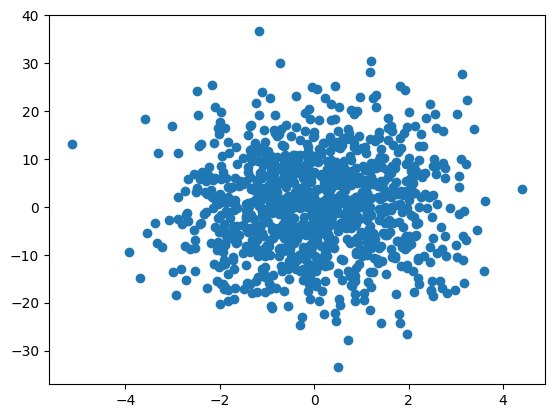

In [8]:
Y, X, W = simulate()
plt.scatter(X, Y)

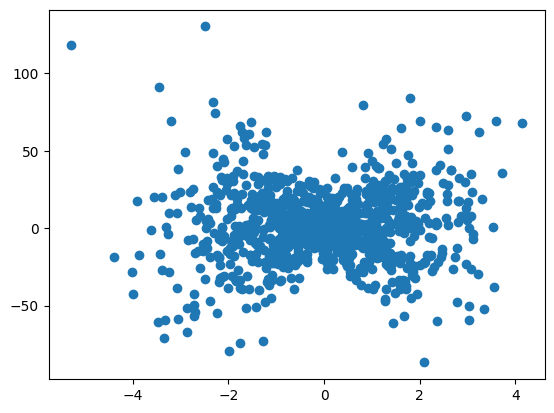

In [9]:
Y, X, W = simulate_heteroskedasticity()
plt.scatter(X, Y)

We can see the errors do not have constant variance, so the simulate method looks to be working correctly

In [10]:
num_trials = 10_000

# Standard errors using statmodel OLS
X_params = []
X_bses = []
for _ in range(num_trials):
    Y, X, W = simulate_heteroskedasticity()
    features = np.column_stack((X, W))
    features = sm.add_constant(features)
    model = sm.OLS(Y, features).fit()
    X_params.append(model.params[1])
    X_bses.append(model.bse[1])
print(f"Std of X coefs after {num_trials}: {np.std(X_params)}")
print(f"Mean X bse: {np.mean(X_bses)}")

# Estimate the standard deviation of the coefficient when there is heteroskedasticity.
# To do this we want to use "Robust Standard Errors"
X_params = []
X_bses = []
for _ in range(num_trials):
    Y, X, W = simulate_heteroskedasticity()
    features = np.column_stack((X, W))
    features = sm.add_constant(features)
    model = sm.OLS(Y, features).fit(cov_type='HC3')
    X_params.append(model.params[1])
    X_bses.append(model.bse[1])
print(f"Std of X coefs after {num_trials}: {np.std(X_params)}")
print(f"Mean X bse: {np.mean(X_bses)}")

Std of X coefs after 10000: 0.9182567180247756
Mean X bse: 0.7251023255126617
Std of X coefs after 10000: 0.917640583309344
Mean X bse: 0.9166487367429578


Based on the results, it looks like regular OLS underestimates the errors versus the robust standard errors. The standard deviation is close between the two

## Reflection Question 2

Write some code that will use a simulation to estimate the standard deviation of the coefficient when errors are highly correlated / non-independent.
Compare these standard errors to those found via statsmodels OlS or a similar linear regression model.

Show that if the correlation between coefficients is high enough, then the estimated standard deviation of the coefficient, using bootstrap errors, might not match that found by a full simulation of the Data Generating Process.  (This can be fixed if you have a huge amount of data for the bootstrap simulation.)

In [36]:
# We will use the regular simulate method, but skip W in the OLS feature set so that the errors include the W
# X is based on W, so this means errors become correlated with X

num_trials = 50_000
X_params = []
for _ in range(num_trials):
    Y, X, W = simulate()
    features = sm.add_constant(X)

    model = sm.OLS(Y, features).fit()

    X_params.append(model.params[1])
# Estimate the standard deviation of the coefficient when errors are highly correlated / non-independent.
std_error = np.std(X_params)
std_error, model.bse[1]

(np.float64(0.22515480770131374), np.float64(0.22245279043540553))

We see the true std of standard errors is around 0.225

In [32]:
# Now we will use bootstrap to estimate the standard deviation of the coefficient.
# Pull a single simulation sample and then sample with replacement in trials
num_bootstrap_trials = 1000
X_bootstrap_params = []

# Pull a single simulation
Y, X, W = simulate()

for _ in range(num_bootstrap_trials):
    # Perform bootstrap sampling
    indices = np.random.choice(len(X), size=len(X), replace=True)
    X_boot = X[indices]
    Y_boot = Y[indices]

    # Fit the model
    features = sm.add_constant(X_boot)
    model = sm.OLS(Y_boot, features).fit()
    X_bootstrap_params.append(model.params[1])

# Estimate the standard deviation of the coefficient using bootstrap
std_error_bootstrap = np.std(X_bootstrap_params)
std_error_bootstrap

np.float64(0.20526363570855025)

The bootstrap underestimates the standard errors, getting around 0.205 instead of the expected 0.225. This could be due to small sample size and noise in the sample

In [37]:
# Now if we use a big enough dataset we can bypass the issue of non-matching standard errors
num_bootstrap_trials = 1000
X_bootstrap_large_params = []

# Pull a single simulation
Y, X, W = simulate(D=100_000)

for _ in range(num_bootstrap_trials):
    # Perform bootstrap sampling
    indices = np.random.choice(len(X), size=len(X), replace=True)
    X_boot = X[indices]
    Y_boot = Y[indices]

    # Fit the model
    features = sm.add_constant(X_boot)
    model = sm.OLS(Y_boot, features).fit()
    X_bootstrap_large_params.append(model.params[1])

# Estimate the standard deviation of the coefficient using bootstrap
std_error_bootstrap = np.std(X_bootstrap_large_params)
std_error_bootstrap

np.float64(0.02272405368965849)

Now we get close to the correct estimation 0.227 vs the expected 0.225 but the scale isn't right (0.0227). After googling I found this is due to law of large numbers "Standard Error shrinks proportionally to the square root of data size"

Expected SE = True SE / (sqrt(100_000/1_000)) = 0.227 / 10 = 0.0227